# YOLO Object Detector (Phase 3)

Goal: detect bulky waste items in an RGB image and output the item class, confidence score, and bounding box.

This notebook is the V1 object-localisation step. The AI model does not calculate CO2e. It provides object evidence that later stages can use for depth sizing, reference matching, and LCA scenario calculations.


In [11]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
realsense_root = project_root / 'data' / 'raw' / 'realsense'
output_dir = project_root / 'data' / 'interim' / 'yolo_detections'
output_dir.mkdir(parents=True, exist_ok=True)

project_root, realsense_root, output_dir


(WindowsPath('d:/Green Waste/V1_GreenWaste'),
 WindowsPath('d:/Green Waste/V1_GreenWaste/data/raw/realsense'),
 WindowsPath('d:/Green Waste/V1_GreenWaste/data/interim/yolo_detections'))

## 1) Check YOLO dependencies

If this cell fails, install the dependency in your active notebook kernel with:

```powershell
python -m pip install ultralytics
```


In [12]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


CUDA available: True
NVIDIA GeForce RTX 5090


## 2) Choose an image

By default this uses the newest RealSense `rgb.png` capture if one exists. You can replace `image_path` with a phone image path.


In [13]:
candidate_images = sorted(realsense_root.glob('capture_*/rgb.png'))
if not candidate_images:
    raise FileNotFoundError("No RealSense rgb.png captures found. Set image_path manually to a phone/image file.")

image_path = candidate_images[-1]

image_path


WindowsPath('d:/Green Waste/V1_GreenWaste/data/raw/realsense/capture_20260527_022745/rgb.png')

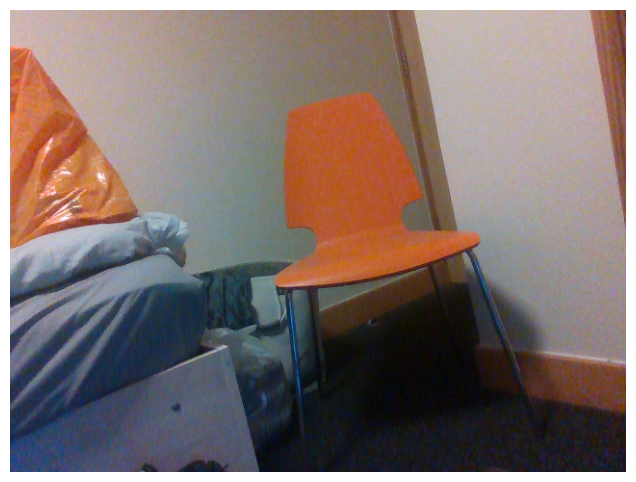

In [14]:
image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise RuntimeError(f"Could not load image: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


## 3) Run pretrained YOLO

This uses a pretrained COCO model. It can detect common objects such as `chair`, `couch`, `bed`, `dining table`, `tv`, and `potted plant`. It will not reliably detect project-specific classes such as `cabinet` or `shelf` unless we train a custom detector later.


In [15]:
# yolo11n is fastest; yolo11s is a stronger default for better detection quality.
preferred_model = 'yolo11s.pt'
local_model_path = project_root / 'models' / preferred_model
model_name = str(local_model_path) if local_model_path.exists() else preferred_model
detector = YOLO(model_name)

device = 0 if torch.cuda.is_available() else 'cpu'
confidence_threshold = 0.20
iou_threshold = 0.50
image_size = 960
use_test_time_augmentation = False

results = detector.predict(
    source=str(image_path),
    conf=confidence_threshold,
    iou=iou_threshold,
    imgsz=image_size,
    augment=use_test_time_augmentation,
    device=device,
    verbose=False,
)

result = results[0]
result.names


{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

## 4) Convert detections into pipeline outputs

Each row gives the object class, confidence score, and bounding box coordinates. These are the values the depth stage needs for ROI-based size estimation.


In [16]:
target_class_map = {
    'chair': 'chair',
    'couch': 'sofa_armchair',
    'bed': 'mattress_bed',
    'dining table': 'table',
    'bench': 'chair',
    'tv': 'storage_or_electrical',
    'potted plant': 'plant_pot',
}

rows = []
for box in result.boxes:
    class_id = int(box.cls.item())
    raw_class = result.names[class_id]
    if raw_class not in target_class_map:
        continue

    x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].tolist()]
    rows.append({
        'source_image': str(image_path.relative_to(project_root)),
        'raw_yolo_class': raw_class,
        'item_class': target_class_map[raw_class],
        'confidence': float(box.conf.item()),
        'x1': round(x1, 2),
        'y1': round(y1, 2),
        'x2': round(x2, 2),
        'y2': round(y2, 2),
        'width_px': round(x2 - x1, 2),
        'height_px': round(y2 - y1, 2),
    })

detections_df = pd.DataFrame(rows)
detections_df


,source_image,raw_yolo_class,item_class,confidence,x1,y1,x2,y2,width_px,height_px
0,data\raw\realsense\capture_20260527_022745\rgb...,chair,chair,0.450622,272.92,83.08,536.29,439.51,263.36,356.43
1,data\raw\realsense\capture_20260527_022745\rgb...,bed,mattress_bed,0.324587,0.51,211.03,208.72,444.55,208.20,233.52


## 5) Draw detections

The drawn boxes are a visual sanity check. The table above is the machine-readable output for the next pipeline stage.


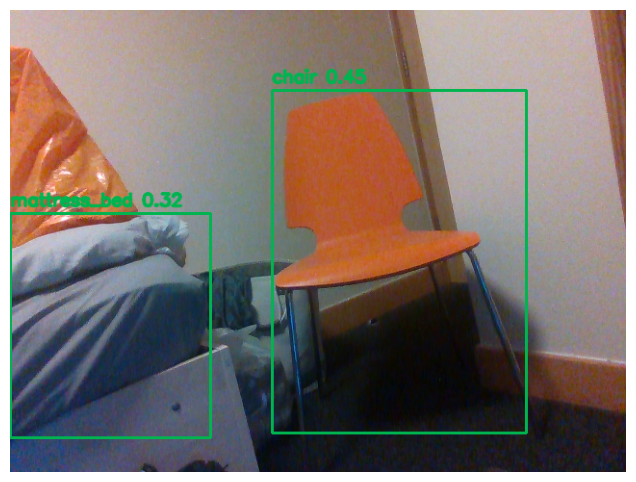

In [17]:
annotated = image_rgb.copy()

for _, row in detections_df.iterrows():
    x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
    label = f"{row.item_class} {row.confidence:.2f}"
    cv2.rectangle(annotated, (x1, y1), (x2, y2), color=(0, 180, 80), thickness=2)
    cv2.putText(
        annotated,
        label,
        (x1, max(y1 - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 180, 80),
        2,
        cv2.LINE_AA,
    )

plt.figure(figsize=(8, 6))
plt.imshow(annotated)
plt.axis('off')
plt.show()


## 6) Save detection outputs

This writes a CSV and annotated image that can be referenced in the methods/results section.


In [18]:
capture_id = image_path.parent.name if image_path.name == 'rgb.png' else image_path.stem
csv_path = output_dir / f'{capture_id}_detections.csv'
annotated_path = output_dir / f'{capture_id}_annotated.png'

detections_df.to_csv(csv_path, index=False)
cv2.imwrite(str(annotated_path), cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

csv_path, annotated_path


(WindowsPath('d:/Green Waste/V1_GreenWaste/data/interim/yolo_detections/capture_20260527_022745_detections.csv'),
 WindowsPath('d:/Green Waste/V1_GreenWaste/data/interim/yolo_detections/capture_20260527_022745_annotated.png'))

## 7) Depth-stage handoff

For a RealSense capture, each bounding box can be used as the ROI for the depth map. This cell only prepares the values. The actual size estimate should use the matching `depth.png` and `metadata.json` from the same capture folder.


In [19]:
if image_path.name == 'rgb.png':
    depth_path = image_path.parent / 'depth.png'
    metadata_path = image_path.parent / 'metadata.json'
    print(f"Depth image exists: {depth_path.exists()} -> {depth_path}")
    print(f"Metadata exists: {metadata_path.exists()} -> {metadata_path}")

    if not detections_df.empty:
        best_detection = detections_df.sort_values('confidence', ascending=False).iloc[0]
        roi = (
            int(best_detection.x1),
            int(best_detection.y1),
            int(best_detection.width_px),
            int(best_detection.height_px),
        )
        print(f"Best detection ROI for depth stage: {roi}")
else:
    print("This is not a RealSense rgb.png capture, so there is no matching depth.png/metadata.json pair.")


Depth image exists: True -> d:\Green Waste\V1_GreenWaste\data\raw\realsense\capture_20260527_022745\depth.png
Metadata exists: True -> d:\Green Waste\V1_GreenWaste\data\raw\realsense\capture_20260527_022745\metadata.json
Best detection ROI for depth stage: (272, 83, 263, 356)
